# Tree plot

Tree plots, more often referred to as compatibility plots, provide information about the parameter space supported by an effect estimate and its standard error. It does this by plotting the support from a zero percent confidence interval (i.e. the point estimate only) towards an approximately 100% confidence interval. 

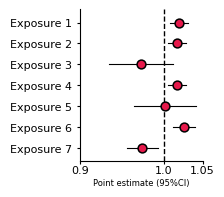

In [1]:
#!/usr/bin/env python3
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

import plot_misc.example_data.examples as examples
import plot_misc.forest as forest
from plot_misc import utils as plm_utils

# Load data
data = examples.load_forest_preprocessed()
CMTOINCH = 1 / 2.54

# Creating a 3 column figure
fig, ax  = plt.subplots(figsize=(4 * CMTOINCH, 5 * CMTOINCH))

# Plot the  forest plot
trees = forest.ForestPlot(
    data=data,
    x_col="coef",
    lb_col="coef lower 95%",
    ub_col="coef upper 95%",
    g_col="Independent",
    ax=ax,
)
trees.plot(
    c_col="col",
    s_size_col=40,
    ci_lwd=0.8,
    ci_colour="black",
    span=False,
    reverse_y=True,
    kwargs_scatter_dict={"edgecolors": "black", "linewidth": 1.1, "zorder": 2},
    kwargs_plot_ci_dict={"zorder": 0},
)

# removing spines
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# reference line
ax.axvline(0, linewidth=1, linestyle="--", c="black", zorder=0)

# setting axes limits and ticks
ax.set_xticks([])
ax.set_xticklabels([])
old_ylim = ax.get_ylim()
ax.set_ylim(old_ylim[0] + 0.5, old_ylim[1] - 0.5)
ax.set_xlim(np.log((0.90, 1.05)))
ax.tick_params(axis="y", labelsize=8, length=2.5)
ax.tick_params(
    axis="x", labelsize=8, length=2.5, pad=0.5
)

# Placing tick labels on log coordinates
plm_utils.utils.change_ticks(ax, ticks=[0.90, 1.00, 1.05], log=True)
_ = ax.set_xlabel("Point estimate (95%CI)", fontsize=6, labelpad=2)

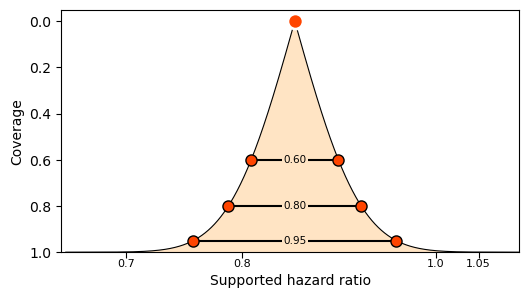

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import plot_misc.forest as forest
from plot_misc import utils as plm_utils

CMTOINCH = 1 / 2.54

# data - mapping hazard ratios to log scale
# and calculating the SE from the reported confidence interval
ESTIMATE = np.log(0.85)
SE = (np.log(0.96) - np.log(0.76)) / 3.92
# getting very close to zero - but never there
ALPHA = list(np.linspace(1, 0.00001, 10000))

# create an axes object
_, ax = plt.subplots(
    figsize=(15 * CMTOINCH, 8 * CMTOINCH),
)

# estimating the support
space = forest.EmpiricalSupport(
    estimate=ESTIMATE, standard_error=SE, alpha=ALPHA
)

# plotting
_ = space.plot_tree(
    ax=ax,
    annotate_estimate=True,
    annotate_ci=[0.95, 0.80, 0.60],
    area_c="bisque",
    linewidth=0.8,
    estimate_c="orangered",
    estimate_size=120,
    kwargs_dot={"edgecolor": "white", "linewidth": 2},
    area_a=1.00,
    kwargs_text={
        "fontsize": 7.5,
        "backgroundcolor": "bisque",
        "bbox": {
            "facecolor": "bisque",
            "alpha": 1.00,
            "edgecolor": "none",
            "pad": 1,
        },
    },
)
# Formatting the axes
plm_utils.utils.change_ticks(ax, ticks=[0.7, 0.8, 1.00, 1.05], log=True)
ax.set_xlim(np.log(0.65), np.log(1.1))
ax.tick_params(axis="x", labelsize=8, length=4, pad=0.5)
ax.set_xlabel("Supported hazard ratio")
_ = ax.set_ylim(1.0, ax.get_ylim()[1])